Poking around, looking for ideas of charts


In [1]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.image as mpimg

In [2]:
# open df's
exp_df = pd.read_csv("../resources/cleaned_expenses.csv")
don_df = pd.read_csv("../resources/cleaned_donations.csv")
reim_df = pd.read_csv("../resources/cleaned_reimbursements.csv")
atten_df = pd.read_csv("../resources/cleaned_attendees.csv")
bar_df = pd.read_csv("../resources/cleaned_bar_expenses.csv")
alc_df = pd.read_csv("../resources/cleaned_alcohol_consumed.csv")

Remove T-shirts (and candles to Scotland)

In [3]:
# total lines in exp_df
print(f"Total lines in exp_df: {len(exp_df)}")

Total lines in exp_df: 114


In [4]:
# Look at Merch
exp_df[exp_df["Category"] == "Merch"]

,Name,Expense,Amount,Year,Category
0,Randy Detman,Key chains,150.00,2017,Merch
5,Tom Brady,Sign stuff,10.00,2017,Merch
17,Randy Detman,Shirts,313.72,2018,Merch
22,Morning Glory,Tie-Dye,55.00,2019,Merch
32,Randy Detman,Tie-Dye Ts,81.64,2019,Merch
39,Tarot,Face paint,20.00,2019,Merch
45,Randy Detman,Tattoos,76.39,2021,Merch
59,Bitter Barbie,T shirts/CustomInk,676.52,2022,Merch
68,Randy Detman,Candles and Scotland Shipping,60.00,2022,Merch
74,Bitter Barbie,T shirts,335.44,2023,Merch


In [5]:
# Extract Candles and Shirts from Merch
exp_df[
    (exp_df["Category"] == "Merch")
    & (exp_df["Expense"].str.contains(r"Candles|shirts", case=False, na=False))
]

,Name,Expense,Amount,Year,Category
17,Randy Detman,Shirts,313.72,2018,Merch
59,Bitter Barbie,T shirts/CustomInk,676.52,2022,Merch
68,Randy Detman,Candles and Scotland Shipping,60.00,2022,Merch
74,Bitter Barbie,T shirts,335.44,2023,Merch
86,Latvia,Sid's shirts,50.00,2023,Merch
88,Bitter Barbie,New t-shirts advance payment,150.00,2023,Merch


In [6]:
# drop these rows from exp_df
mask = (exp_df["Category"] == "Merch") & (
    exp_df["Expense"].str.contains(r"Candles|shirts", case=False, na=False)
)
to_deduct = exp_df[mask]

# print donations per year
print(don_df)

# sum and deduct from donations
deduct_per_year = to_deduct.groupby("Year")["Amount"].sum()
for year, amount in deduct_per_year.items():
    don_df.loc[don_df["Year"] == year, "Donations"] -= amount

# print donations per year after deduction
print(don_df)

# now drop from exp_df
exp_df = exp_df.drop(to_deduct.index)

# check length again
print(f"Total lines in exp_df after drop: {len(exp_df)}")

# Look at Merch
exp_df[exp_df["Category"] == "Merch"]

   Year  Donations
0  2024     1857.0
1  2023     5095.0
2  2022     5485.0
3  2021     1981.0
4  2019     3242.4
5  2018     1884.0
6  2017     1214.0
   Year  Donations
0  2024    1857.00
1  2023    4559.56
2  2022    4748.48
3  2021    1981.00
4  2019    3242.40
5  2018    1570.28
6  2017    1214.00
Total lines in exp_df after drop: 108


,Name,Expense,Amount,Year,Category
0,Randy Detman,Key chains,150.00,2017,Merch
5,Tom Brady,Sign stuff,10.00,2017,Merch
22,Morning Glory,Tie-Dye,55.00,2019,Merch
32,Randy Detman,Tie-Dye Ts,81.64,2019,Merch
39,Tarot,Face paint,20.00,2019,Merch
45,Randy Detman,Tattoos,76.39,2021,Merch
84,Watsonville,Piñata and mini bottles,60.00,2023,Merch


# Plots!

### Attendees

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


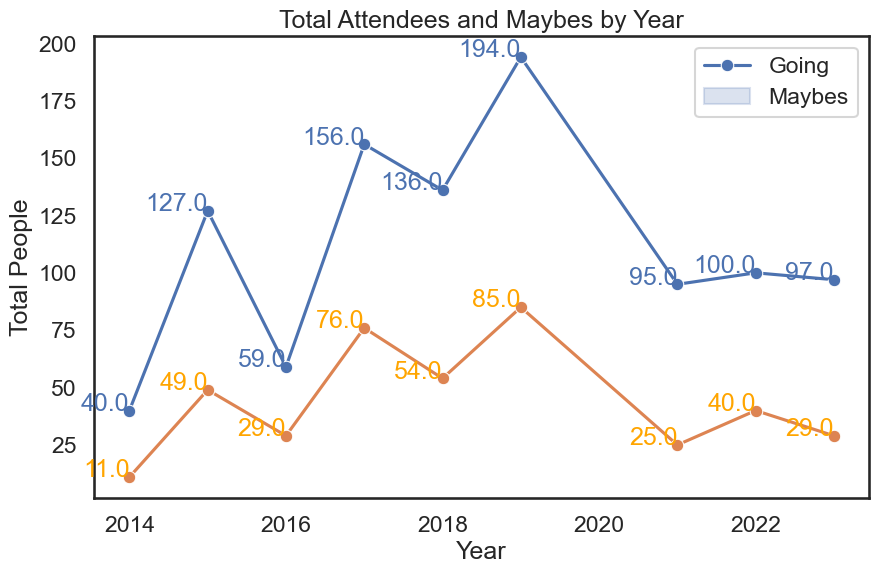

In [7]:
# plot attendees over time
# line chart of attendees and maybes by year

# plot the chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
sns.lineplot(x="Year", y="Going", data=atten_df, marker="o")
sns.lineplot(x="Year", y="Maybes", data=atten_df, marker="o")

# annotate each data point
for _, row in atten_df.iterrows():
    year = row.Year
    going = row.Going
    maybes = row.Maybes
    plt.text(year, going, f"{going}", horizontalalignment="right", color="b")
    plt.text(year, maybes, f"{maybes}", horizontalalignment="right", color="orange")

# format plot
plt.title("Total Attendees and Maybes by Year")
plt.xlabel("Year")
plt.ylabel("Total People")
plt.legend(["Going", "Maybes"])
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


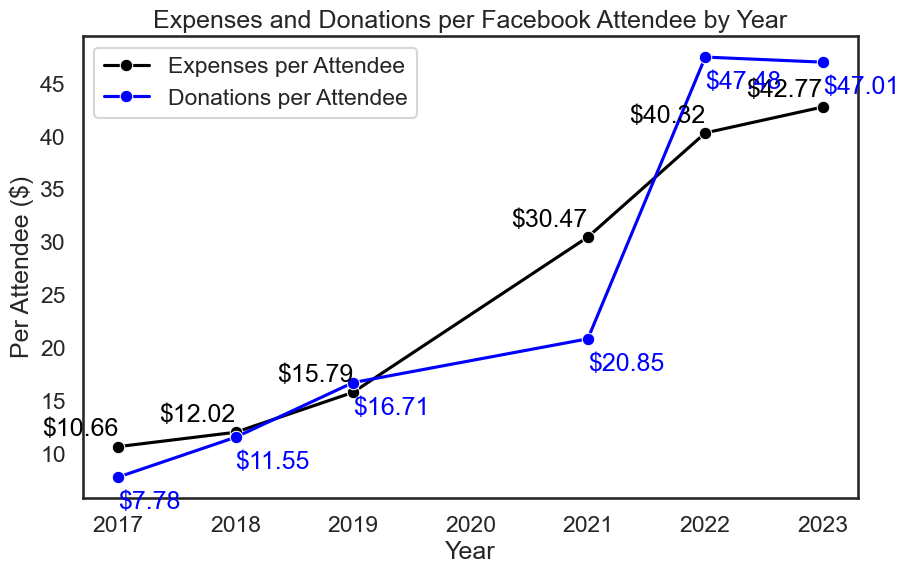

In [8]:
# cost per attendee over time
# plot of expenses per attendee by year

# group and sort sums by year, 2017+
df_sum = exp_df[exp_df.Year >= 2017].groupby("Year")["Amount"].sum().reset_index()
att_sum = atten_df[atten_df.Year >= 2017].copy()

# merge dfs
df_sum = pd.merge(df_sum, att_sum, on="Year", how="outer")

# calculate expenses per attendee
df_sum["Expenses_per_attendee"] = df_sum["Amount"] / df_sum["Going"]

# merge don_df with df_sum
df_sum = pd.merge(df_sum, don_df, on="Year", how="outer")

# calculate donations per attendee
df_sum["Donations_per_attendee"] = df_sum["Donations"] / df_sum["Going"]

# plot and format line chart for expenses
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="Year",
    y="Expenses_per_attendee",
    data=df_sum,
    marker="o",
    color="black",
    label="Expenses per Attendee",
)

# plot and format line chart for donations
sns.lineplot(
    x="Year",
    y="Donations_per_attendee",
    data=df_sum,
    marker="o",
    color="blue",
    label="Donations per Attendee",
)

# annotate each data point for expenses
for _, row in df_sum.iterrows():
    year = row.Year
    amount = row.Expenses_per_attendee
    plt.text(
        year, amount + 1, f"${amount:.2f}", horizontalalignment="right", color="black"
    )

# annotate each data point for donations
for _, row in df_sum.iterrows():
    year = row.Year
    donation = row.Donations_per_attendee
    plt.text(
        year, donation - 3, f"${donation:.2f}", horizontalalignment="left", color="blue"
    )

# format plot
plt.title("Expenses and Donations per Facebook Attendee by Year")
plt.xlabel("Year")
plt.ylabel("Per Attendee ($)")
plt.show()

### Expenses

In [9]:
# print total expenses per year
for year, group in exp_df.groupby("Year"):
    total = group["Amount"].sum()
    print(f"Total expenses for {year}: ${total:,.2f}")

Total expenses for 2017: $1,663.00
Total expenses for 2018: $1,634.58
Total expenses for 2019: $3,063.35
Total expenses for 2021: $2,894.85
Total expenses for 2022: $4,031.68
Total expenses for 2023: $4,148.30
Total expenses for 2024: $2,152.00


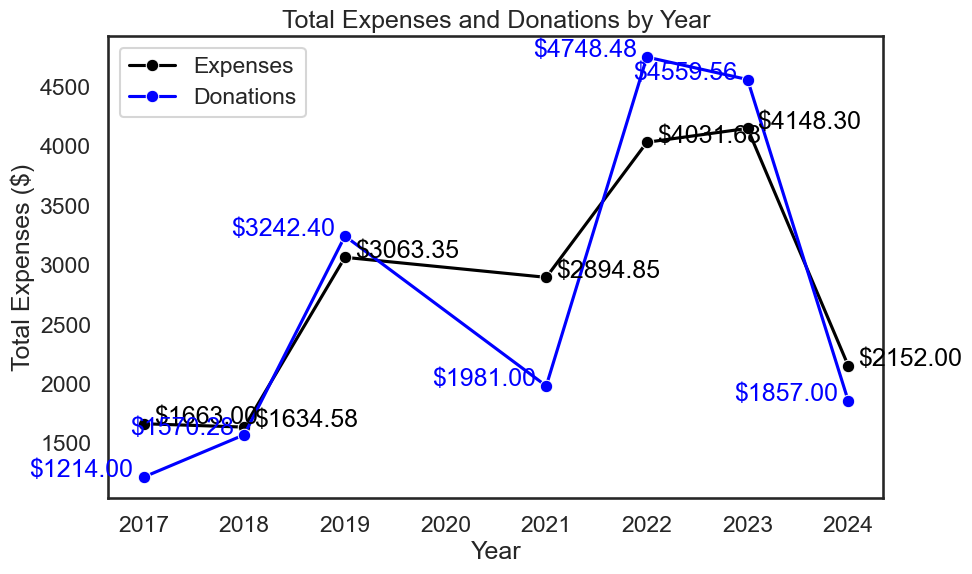

In [10]:
# plot expenses and donations by year as a line chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="Year",
    y="Amount",
    data=exp_df,
    estimator="sum",
    errorbar=None,
    marker="o",
    color="black",
)
sns.lineplot(
    x="Year", y="Donations", data=don_df, errorbar=None, marker="o", color="blue"
)

# annotate each data point
df_sum = exp_df.groupby("Year")["Amount"].sum()
for year, amount in df_sum.items():
    plt.text(
        year + 0.1, amount, f"${amount:.2f}", horizontalalignment="left", color="black"
    )
for _, row in don_df.iterrows():
    year = row.Year
    amount = row.Donations
    plt.text(
        year - 0.1, amount, f"${amount:.2f}", horizontalalignment="right", color="blue"
    )

# format plot
plt.title("Total Expenses and Donations by Year")
plt.xlabel("Year")
plt.ylabel("Total Expenses ($)")
plt.legend(["Expenses", "Donations"])
plt.show()

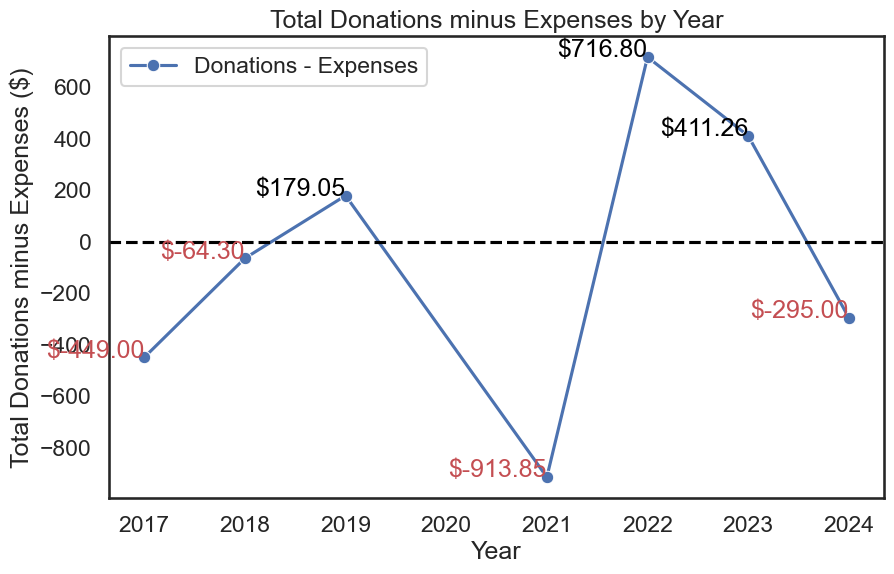

In [11]:
# plot donations minus expenses by year as a line chart

# group and sum expenses by year
df_sum = exp_df.groupby("Year")["Amount"].sum().reset_index()
df_sum.columns = ["Year", "Amount"]

don_sum = don_df.copy()  # donations df

# merge expenses and donations dfs
df_sum = pd.merge(df_sum, don_sum, on="Year", how="outer")

# calculate expenses minus donations
df_sum["Donations_minus_expenses"] = df_sum["Donations"] - df_sum["Amount"]

# plot and format line chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))

sns.lineplot(
    x="Year",
    y="Donations_minus_expenses",
    data=df_sum,
    marker="o",
    # color="r",
    label="Donations - Expenses",
)

# Add a horizontal line at y=0
plt.axhline(0, color="black", linestyle="--")

# annotate each data point
for _, row in df_sum.iterrows():
    year = row.Year
    amount = row.Donations_minus_expenses
    color = "r" if amount < 0 else "black"
    plt.text(year, amount, f"${amount:.2f}", horizontalalignment="right", color=color)

# format plot
plt.title("Total Donations minus Expenses by Year")
plt.xlabel("Year")
plt.ylabel("Total Donations minus Expenses ($)")
plt.show()

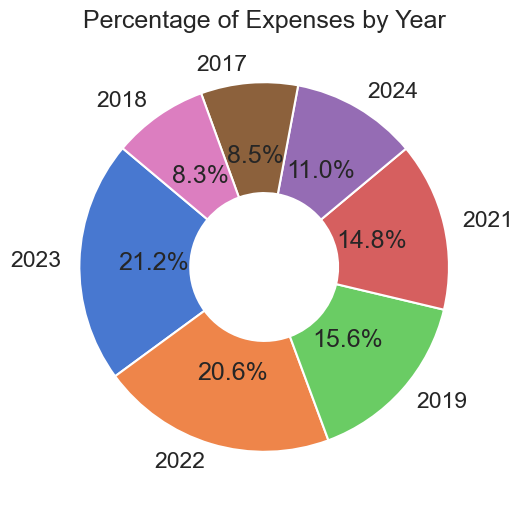

In [12]:
# plot total expenses by year as a donut chart

# group and sort sums by year
df_sum = exp_df.groupby("Year")["Amount"].sum().reset_index()
df_sum = df_sum.sort_values("Amount", ascending=False)

# plot and format donut chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
plt.pie(
    df_sum.Amount,
    labels=df_sum.Year,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("muted"),
    wedgeprops=dict(width=0.6, edgecolor="w"),
)
plt.title("Percentage of Expenses by Year")
plt.show()

### Itemized Expenses

<Figure size 1000x600 with 0 Axes>

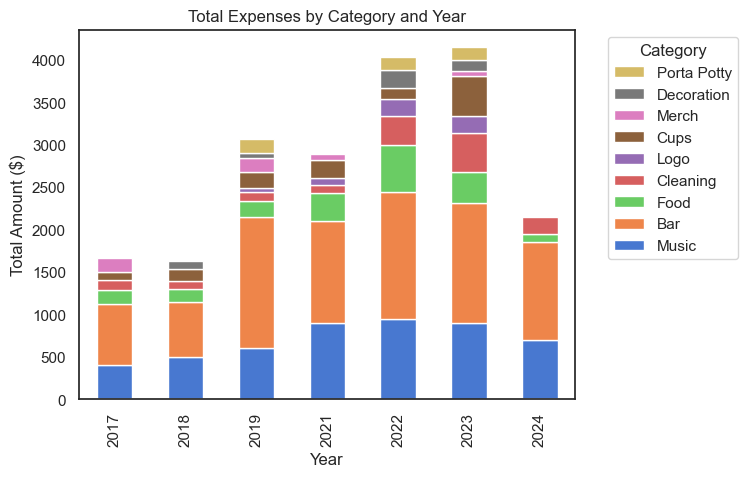

In [13]:
# Stacked bar chart of expenses by category and year

# Order categories
category_order = [
    "Music",
    "Bar",
    "Food",
    "Cleaning",
    "Logo",
    "Cups",
    "Merch",
    "Decoration",
    "Porta Potty",
]

# plot a grouped bar chart of expenses by category, per year
df_cat = exp_df.groupby(["Year", "Category"])["Amount"].sum().reset_index()
df_cat = df_cat.pivot(index="Year", columns="Category", values="Amount").reset_index()
df_cat = df_cat.fillna(0)

# Reorder columns
cols = ["Year"] + [cat for cat in category_order if cat in df_cat.columns]
df_cat = df_cat[cols]

# plot the chart
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))
ax = df_cat.plot(x="Year", kind="bar", stacked=True, color=sns.color_palette("muted"))

# format plot
plt.title("Total Expenses by Category and Year")
plt.xlabel("Year")
plt.ylabel("Total Amount ($)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left", reverse=True)
plt.show()

In [14]:
# Plotly stacked bar chart of expenses by category and year

# Order categories
category_order = [
    "Music",
    "Bar",
    "Food",
    "Cleaning",
    "Logo",
    "Cups",
    "Merch",
    "Decoration",
    "Porta Potty",
]

# Prepare data in long format
df_cat = exp_df.groupby(["Year", "Category"])["Amount"].sum().reset_index()

# Plotly stacked bar chart
fig = px.bar(
    df_cat,
    x="Year",
    y="Amount",
    color="Category",
    category_orders={"Category": category_order},
    title="Total Expenses by Category and Year",
    labels={"Amount": "Total Amount ($)", "Year": "Year", "Category": "Category"},
    text_auto=".0f",
)

fig.update_layout(
    barmode="stack",
    legend_title_text="Category",
    legend_orientation="h",
    legend_yanchor="bottom",
    legend_y=-0.2,
    legend_xanchor="center",
    legend_x=0.5,
)

fig.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\plotly\express\_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


In [15]:
# Prepare data
df_cat = exp_df.groupby(["Year", "Category"])["Amount"].sum().reset_index()
categories = df_cat["Category"].unique()
years = sorted(df_cat["Year"].unique())

# Create a bar trace and a text trace for each category
data = []
for i, cat in enumerate(categories):
    y_vals = [
        df_cat[(df_cat["Year"] == year) & (df_cat["Category"] == cat)]["Amount"].sum()
        for year in years
    ]
    # Bar trace
    data.append(
        go.Bar(
            x=years,
            y=y_vals,
            name=cat,
            visible=(i == 0),  # Only first category visible at start
        )
    )
    # Text trace for totals
    data.append(
        go.Scatter(
            x=years,
            y=y_vals,
            text=[f"${y:,.0f}" if y > 0 else "" for y in y_vals],
            mode="text",
            textposition="top center",
            showlegend=False,
            visible=(i == 0),
        )
    )

# Create dropdown buttons
buttons = []
for i, cat in enumerate(categories):
    # Only show the bar and text trace for the selected category
    visible = [False] * (2 * len(categories))
    visible[2 * i] = True  # Bar
    visible[2 * i + 1] = True  # Text
    buttons.append(
        dict(
            label=cat,
            method="update",
            args=[{"visible": visible}, {"title": f"Expenses for {cat} by Year"}],
        )
    )

# Add "Show All" option (show all bars, hide all text)
visible_all = []
for i in range(len(categories)):
    visible_all.extend([True, False])  # Show bar, hide text
buttons.insert(
    0,
    dict(
        label="Show All",
        method="update",
        args=[{"visible": visible_all}, {"title": "Expenses by Category and Year"}],
    ),
)

# Create the figure
fig = go.Figure(data=data)
fig.update_layout(
    updatemenus=[
        dict(active=0, buttons=buttons, x=0.85, y=1.15, xanchor="left", yanchor="top")
    ],
    barmode="group",
    title=f"Expenses for {categories[0]} by Year",
    xaxis_title="Year",
    yaxis_title="Total Amount ($)",
    legend_orientation="h",  # horizontal legend
    legend_yanchor="bottom",
    legend_y=-0.2,  # move below plot
    legend_xanchor="center",
    legend_x=0.5,
)

fig.show()

In [16]:
# stacked bar chart of bar expenses by type and year

# Group by Year and Type, sum Amount
bar_type_sum = bar_df.groupby(["Year", "Type"])["Amount"].sum().reset_index()

# Create stacked bar chart
fig = px.bar(
    bar_type_sum,
    x="Year",
    y="Amount",
    color="Type",
    title="Bar Expenses by Type per Year",
    labels={"Amount": "Total Amount ($)", "Year": "Year", "Type": "Type"},
    text_auto=True,
)

fig.update_layout(
    barmode="stack",
    legend_title_text="Type",
    legend_orientation="h",
    legend_yanchor="bottom",
    legend_y=-0.2,
    legend_xanchor="center",
    legend_x=0.5,
)

fig.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [17]:
# Donut chart of expenses by category and year with dropdown to select year
# Prepare data
category_order = [
    "Music",
    "Bar",
    "Food",
    "Cleaning",
    "Logo",
    "Cups",
    "Merch",
    "Decoration",
    "Porta Potty",
]
years = sorted(exp_df["Year"].unique())
data = []
buttons = []

for i, year in enumerate(years):
    df_year = exp_df[exp_df["Year"] == year]
    sums = df_year.groupby("Category")["Amount"].sum().reindex(category_order).fillna(0)
    # Donut chart trace for this year
    data.append(
        go.Pie(
            labels=category_order,
            values=sums.values,
            name=str(year),
            hole=0.5,
            visible=(i == 0),  # Only first year visible at start
            textinfo="percent+label",
            hovertemplate="%{label}: $%{value:,.0f}<extra></extra>",
        )
    )
    # Button for this year
    visible = [False] * len(years)
    visible[i] = True
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[{"visible": visible}, {"title": f"Expenses by Category for {year}"}],
        )
    )

# Create figure
fig = go.Figure(data=data)
fig.update_layout(
    title=f"Expenses by Category for {years[0]}",
    updatemenus=[
        dict(active=0, buttons=buttons, x=1, y=1.15, xanchor="center", yanchor="top")
    ],
)
fig.show()

In [18]:
# treemap of expenses by category and year

# group and sort sums by Category and Year
df_cat_year_sum = exp_df.groupby(["Category", "Year"]).sum().reset_index()

# calculate percentage of total expenses for each category-year combination
df_cat_year_sum["Percentage"] = df_cat_year_sum.groupby("Year")["Amount"].transform(
    lambda x: x / x.sum() * 100
)

# plot the chart
fig = px.treemap(
    df_cat_year_sum,
    path=["Year", "Category"],
    values="Percentage",
    color="Year",
    color_continuous_scale="Viridis",
    title="Treemap Chart of Expenses by Category and Year (Hover for more info)",
    custom_data=["Percentage", "Amount"],
)

# update layout for better display
fig.update_layout(
    height=600,
    width=800,
    uniformtext=dict(minsize=12, mode="hide"),
)

# format percentage
fig.update_traces(
    hovertemplate="Year: %{parent}<br>Category: %{label}<br>Percentage: %{customdata[0]:.2f}%<br>Amount: $%{customdata[1]:.2f}"
)

fig.show()

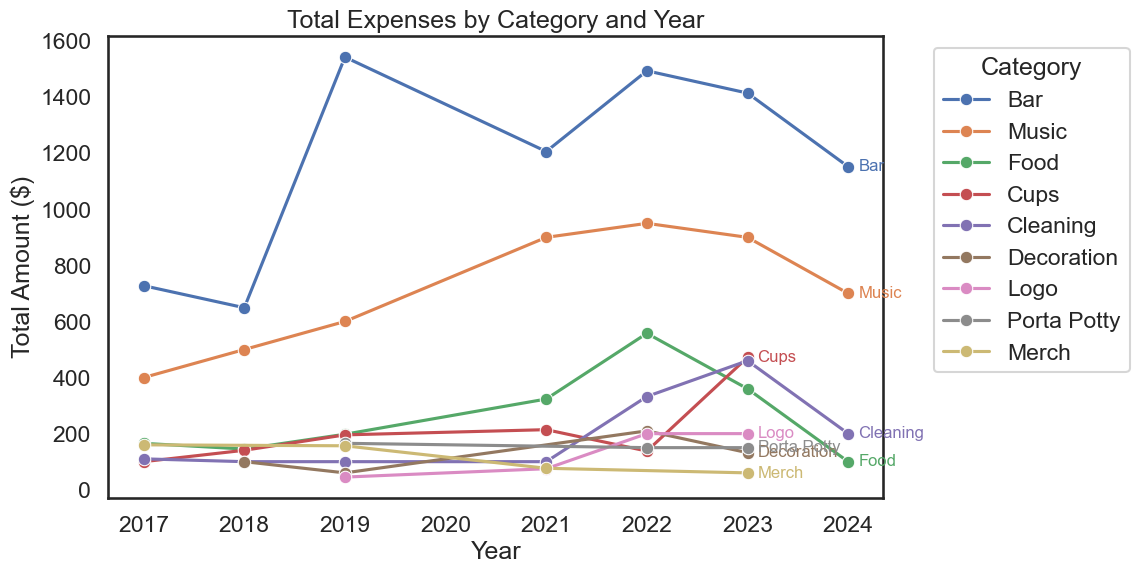

In [19]:
# line chart of expenses by category over time

# group and sort sums by Category and Year
df_cat_year_sum = exp_df.groupby(["Category", "Year"]).sum().reset_index()
df_cat_year_sum = df_cat_year_sum.sort_values("Amount", ascending=False)

# plot the chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    x="Year", y="Amount", hue="Category", data=df_cat_year_sum, marker="o"
)

# annotate each line with the name of the category
for line, name in zip(ax.lines, df_cat_year_sum["Category"].unique()):
    y = line.get_ydata()[-1]
    x = line.get_xdata()[-1]
    ax.text(
        x + 0.1, y, name, color=line.get_color(), size=12, verticalalignment="center"
    )

# format plot
plt.title("Total Expenses by Category and Year")
plt.xlabel("Year")
plt.ylabel("Total Amount ($)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

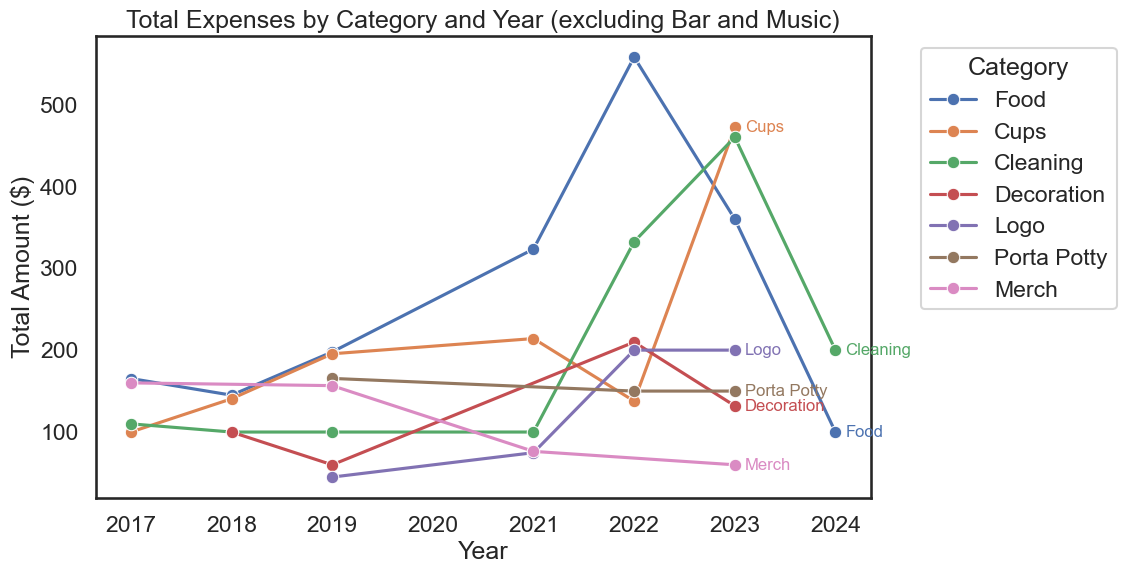

In [20]:
# line chart of expenses by category over time, without Bar and Music

# group and sort sums by Category and Year
df_cat_year_sum = exp_df[exp_df.Category != "Bar"]
df_cat_year_sum = df_cat_year_sum[df_cat_year_sum.Category != "Music"]
df_cat_year_sum = df_cat_year_sum.groupby(["Category", "Year"]).sum().reset_index()
df_cat_year_sum = df_cat_year_sum.sort_values("Amount", ascending=False)

# plot the chart
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    x="Year", y="Amount", hue="Category", data=df_cat_year_sum, marker="o"
)

# annotate each line with the name of the category
for line, name in zip(ax.lines, df_cat_year_sum["Category"].unique()):
    y = line.get_ydata()[-1]
    x = line.get_xdata()[-1]
    ax.text(
        x + 0.1, y, name, color=line.get_color(), size=12, verticalalignment="center"
    )

# format plot
plt.title("Total Expenses by Category and Year (excluding Bar and Music)")
plt.xlabel("Year")
plt.ylabel("Total Amount ($)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [21]:
# group and sort sums by Category and Year
df_cat_year_sum = exp_df.groupby(["Category", "Year"]).sum().reset_index()

# Order categories
category_order = [
    "Music",
    "Bar",
    "Food",
    "Cleaning",
    "Logo",
    "Cups",
    "Merch",
    "Decoration",
    "Porta Potty",
]

# create boxplot with all points and a different color for each category
fig = px.box(
    df_cat_year_sum,
    x="Category",
    y="Amount",
    color="Category",
    points="all",
    hover_data={"Amount": ":$.2f", "Year": True},
    category_orders={"Category": category_order},
)

# format plot
fig.update_layout(
    title="Total Expenses by Category and Year (Hover for more info)",
    xaxis_title="Category",
    yaxis_title="Total Amount ($)",
    legend_orientation="h",  # horizontal legend
    legend_yanchor="bottom",
    legend_y=-0.2,  # move below plot
    legend_xanchor="center",
    legend_x=0.5,
)

# show the plot
fig.show()

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



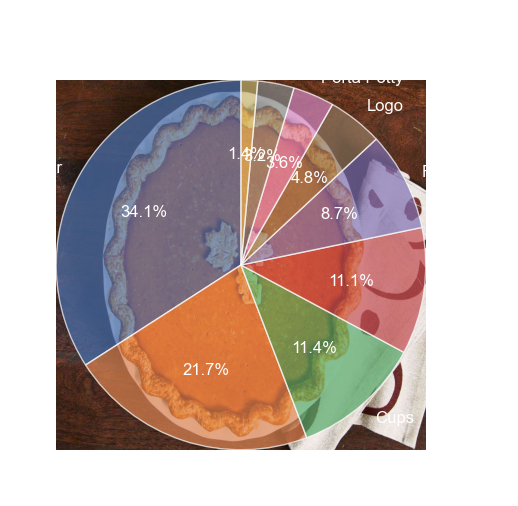

In [22]:
# plot pie chart of expenses by category for 2023 on image of pumpkin pie
# filter exp_df for 2023
exp_2023 = exp_df[exp_df["Year"] == 2023]
# group by category and sum amounts
exp_2023_sum = exp_2023.groupby("Category")["Amount"].sum().reset_index()
# sort by amount descending
exp_2023_sum = exp_2023_sum.sort_values("Amount", ascending=False)
# load pumpkin pie image
img = mpimg.imread("pumpkin_pie.jpg")
# create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, extent=[-1, 1, -1, 1], zorder=0)
# ax.axis('off')
# create pie chart
wedges, texts, autotexts = ax.pie(
    exp_2023_sum["Amount"],
    labels=exp_2023_sum["Category"],
    autopct="%1.1f%%",
    startangle=90,
)
# style pie chart
for text in texts + autotexts:
    text.set_color("white")
    text.set_fontsize(12)
for wedge in wedges:
    wedge.set_edgecolor("white")
    wedge.set_linewidth(1)
    wedge.set_alpha(0.7)
# set title
ax.set_title("2023 Expenses by Category", color="white", fontsize=16)
# show plot
plt.show()

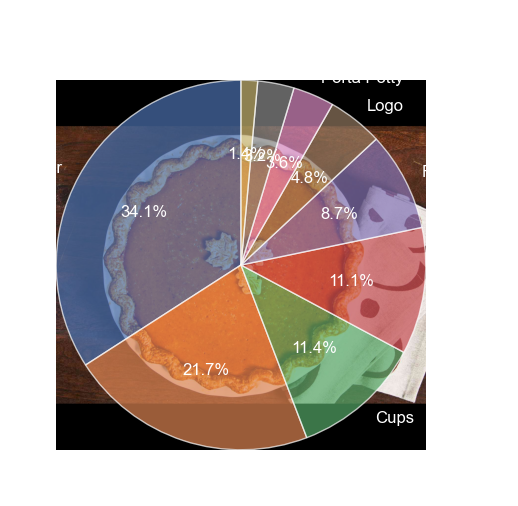

In [23]:
# plot pie chart of expenses by category for 2023 on image of pumpkin pie
from PIL import Image

# filter exp_df for 2023
exp_2023 = exp_df[exp_df["Year"] == 2023]
# group by category and sum amounts
exp_2023_sum = exp_2023.groupby("Category")["Amount"].sum().reset_index()
# sort by amount descending
exp_2023_sum = exp_2023_sum.sort_values("Amount", ascending=False)

# load pumpkin pie image
img = Image.open("pumpkin_pie.jpg")
# Crop or pad to square
size = max(img.size)
new_img = Image.new("RGB", (size, size), (0, 0, 0))  # black background
new_img.paste(img, ((size - img.size[0]) // 2, (size - img.size[1]) // 2))
img_arr = np.array(new_img)

# create figure and axis
fig, ax = plt.subplots(figsize=(6, 6), facecolor="none")
ax.imshow(img_arr, extent=[-1, 1, -1, 1], zorder=0)
ax.axis("off")
fig.patch.set_alpha(0)

# create pie chart
wedges, texts, autotexts = ax.pie(
    exp_2023_sum["Amount"],
    labels=exp_2023_sum["Category"],
    autopct="%1.1f%%",
    startangle=90,
)
# style pie chart
for text in texts + autotexts:
    text.set_color("white")
    text.set_fontsize(12)
for wedge in wedges:
    wedge.set_edgecolor("white")
    wedge.set_linewidth(1)
    wedge.set_alpha(0.7)
# set title
ax.set_title("2023 Expenses by Category", color="white", fontsize=16)
# show plot
plt.show()

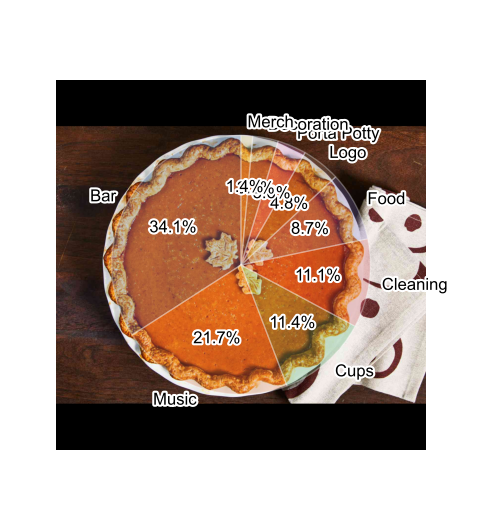

In [24]:
# plot pie chart of expenses by category for 2023 on image of pumpkin pie
from PIL import Image
import matplotlib.patheffects as path_effects

# filter exp_df for 2023
exp_2023 = exp_df[exp_df["Year"] == 2023]
# group by category and sum amounts
exp_2023_sum = exp_2023.groupby("Category")["Amount"].sum().reset_index()
# sort by amount descending
exp_2023_sum = exp_2023_sum.sort_values("Amount", ascending=False)

# load pumpkin pie image
img = Image.open("pumpkin_pie.jpg")
# Crop or pad to square
size = max(img.size)
new_img = Image.new("RGB", (size, size), (0, 0, 0))  # black background
new_img.paste(img, ((size - img.size[0]) // 2, (size - img.size[1]) // 2))
img_arr = np.array(new_img)

# create figure and axis
fig, ax = plt.subplots(figsize=(6, 6), facecolor="none")
ax.imshow(img_arr, extent=[-1, 1, -1, 1], zorder=0)
ax.axis("off")
fig.patch.set_alpha(0)

# create pie chart
wedges, texts, autotexts = ax.pie(
    exp_2023_sum["Amount"],
    labels=exp_2023_sum["Category"],
    autopct="%1.1f%%",
    startangle=90,
    radius=0.7  # shrink the pie
)
# style pie chart
for text in texts + autotexts:
    text.set_color("black")
    text.set_fontsize(12)
    text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
for wedge in wedges:
    wedge.set_edgecolor("white")
    wedge.set_linewidth(1)
    wedge.set_alpha(0.3)
# set title
ax.set_title("2023 Expenses by Category", color="white", fontsize=16)
# show plot
plt.show()

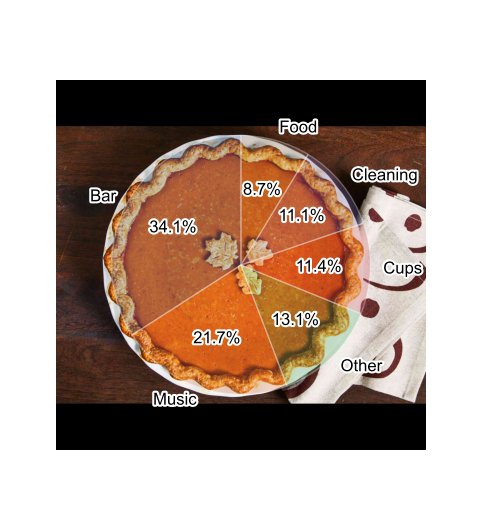

In [25]:
# plot pie chart of expenses by category for 2023 on image of pumpkin pie
from PIL import Image
import matplotlib.patheffects as path_effects
def autopct_format(pct):
    total = exp_2023_sum["Amount"].sum()
    val = int(round(pct/100.*total))
    return f"${val:,}\n({pct:.1f}%)"

# filter exp_df for 2023
main_cats = ["Bar", "Music", "Food", "Cleaning", "Cups"]
exp_2023 = exp_df[exp_df['Year'] == 2023].copy()
exp_2023['Category'] = exp_2023['Category'].where(exp_2023['Category'].isin(main_cats), 'Other')
# group by category and sum amounts
exp_2023_sum = exp_2023.groupby("Category")["Amount"].sum().reset_index()
# sort by amount descending
exp_2023_sum = exp_2023_sum.sort_values("Amount", ascending=False)

# load pumpkin pie image
img = Image.open("pumpkin_pie.jpg")
# Crop or pad to square
size = max(img.size)
new_img = Image.new("RGB", (size, size), (0, 0, 0))  # black background
new_img.paste(img, ((size - img.size[0]) // 2, (size - img.size[1]) // 2))
img_arr = np.array(new_img)

# create figure and axis
fig, ax = plt.subplots(figsize=(6, 6), facecolor="none")
ax.imshow(img_arr, extent=[-1, 1, -1, 1], zorder=0)
ax.axis("off")
fig.patch.set_alpha(0)

# create pie chart
wedges, texts, autotexts = ax.pie(
    exp_2023_sum["Amount"],
    labels=exp_2023_sum["Category"],
    autopct="%1.1f%%",
    # autopct=lambda pct: "${:,.0f}".format(pct/100.*exp_2023_sum["Amount"].sum()),
    # autopct=autopct_format,
    startangle=90,
    radius=0.7  # shrink the pie
)
# style pie chart
for text in texts + autotexts:
    text.set_color("black")
    text.set_fontsize(12)
    text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
for wedge in wedges:
    wedge.set_edgecolor("white")
    wedge.set_linewidth(1)
    wedge.set_alpha(0.3)
# set title
ax.set_title("2023 Expenses by Category", color="white", fontsize=16)
# show plot
plt.show()

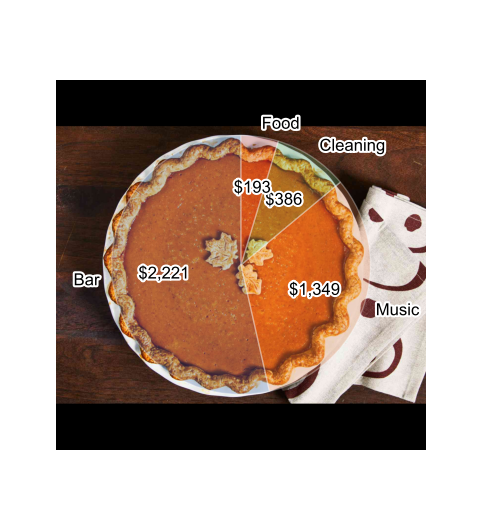

In [26]:
# plot pie chart of expenses by category for 2024 on image of pumpkin pie
from PIL import Image
import matplotlib.patheffects as path_effects
def autopct_format(pct):
    total = exp_2023_sum["Amount"].sum()
    val = int(round(pct/100.*total))
    return f"${val:,}\n({pct:.1f}%)"

# filter exp_df for 2024
exp_2024 = exp_df[exp_df["Year"] == 2024]
# group by category and sum amounts
exp_2024_sum = exp_2024.groupby("Category")["Amount"].sum().reset_index()
# sort by amount descending
exp_2024_sum = exp_2024_sum.sort_values("Amount", ascending=False)

# load pumpkin pie image
img = Image.open("pumpkin_pie.jpg")
# Crop or pad to square
size = max(img.size)
new_img = Image.new("RGB", (size, size), (0, 0, 0))  # black background
new_img.paste(img, ((size - img.size[0]) // 2, (size - img.size[1]) // 2))
img_arr = np.array(new_img)

# create figure and axis
fig, ax = plt.subplots(figsize=(6, 6), facecolor="none")
ax.imshow(img_arr, extent=[-1, 1, -1, 1], zorder=0)
ax.axis("off")
fig.patch.set_alpha(0)

# create pie chart
wedges, texts, autotexts = ax.pie(
    exp_2024_sum["Amount"],
    labels=exp_2024_sum["Category"],
    # autopct="%1.1f%%",
    autopct=lambda pct: "${:,.0f}".format(pct/100.*exp_2023_sum["Amount"].sum()),
    # autopct=autopct_format,
    startangle=90,
    radius=0.7  # shrink the pie
)
# style pie chart
for text in texts + autotexts:
    text.set_color("black")
    text.set_fontsize(12)
    text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
for wedge in wedges:
    wedge.set_edgecolor("white")
    wedge.set_linewidth(1)
    wedge.set_alpha(0.3)
# set title
ax.set_title("2024 Expenses by Category", color="white", fontsize=16)
# show plot
plt.show()